# Tabular Regression with Fully Connected Networks (PyTorch Practice)

**Goal:** Train a **fully connected neural network (MLP)** on a **benchmark tabular dataset** as a **regression** task.

Dataset: **Diabetes** (from `sklearn.datasets.load_diabetes`)  
Target: continuous disease progression measure (already regression)

You will practice the full workflow:
data loading → preprocessing → train/val split → PyTorch Dataset/DataLoader → model → training loop → evaluation → visualization.

## 0) Setup
We use:
- `scikit-learn` to load a standard tabular benchmark dataset
- `StandardScaler` for feature scaling
- PyTorch for model + training loop

In [1]:

import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [75]:

def set_seed(seed: int = 42): #Used to help reproduce work
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Load and preprocess the tabular dataset

We standardize features (zero mean, unit variance) using **training-set statistics** only.

In [76]:

data = load_diabetes()
X = data.data.astype(np.float32)   # shape [N, d]
y = data.target.astype(np.float32) # shape [N,]
X.shape, y.shape

((442, 10), (442,))

In [77]:

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.1, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# Optional: scale y to improve optimization stability (common in regression)
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = ((y_train - y_mean) / y_std).astype(np.float32)
y_test_s  = ((y_test  - y_mean) / y_std).astype(np.float32)

X_train.shape, X_test.shape, y_train_s.mean(), y_train_s.std()

((397, 10), (45, 10), np.float32(6.4859464e-08), np.float32(1.0))

## 2) Build PyTorch datasets + loaders

In [84]:

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train_s).unsqueeze(1))  # y: [N,1]
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test_s).unsqueeze(1))

batch_size = 100
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
xb.shape, yb.shape

(torch.Size([100, 10]), torch.Size([100, 1]))

## 3) Define an MLP regressor

Output must be shape `[B, 1]`.

In [85]:

class MLPRegressor(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(in_dim=X_train.shape[1]).to(device)
model

MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 4) Training + evaluation loops

Metrics on the **scaled target**:
- MSE, RMSE, MAE

We also report metrics in **original units** by unscaling predictions:
`y = y_scaled * y_std + y_mean`

In [86]:

@torch.no_grad()
def evaluate(model, loader, criterion, y_mean: float, y_std: float):
    model.eval()
    total_loss = 0.0
    total_abs = 0.0
    total_sq = 0.0
    n = 0

    # For original-scale metrics
    total_abs_orig = 0.0
    total_sq_orig = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_abs  += torch.sum(torch.abs(pred - yb)).item()
        total_sq   += torch.sum((pred - yb) ** 2).item()

        # Unscale
        pred_orig = pred * y_std + y_mean
        yb_orig   = yb   * y_std + y_mean
        total_abs_orig += torch.sum(torch.abs(pred_orig - yb_orig)).item()
        total_sq_orig  += torch.sum((pred_orig - yb_orig) ** 2).item()

        n += bs

    mse = total_sq / n
    rmse = math.sqrt(mse)
    mae = total_abs / n

    mse_o = total_sq_orig / n
    rmse_o = math.sqrt(mse_o)
    mae_o = total_abs_orig / n

    return {
        "mse": total_loss / n,
        "rmse": rmse,
        "mae": mae,
        "mse_orig": mse_o,
        "rmse_orig": rmse_o,
        "mae_orig": mae_o,
    }

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n

## 5) Run training

In [87]:

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 100
history = {
    "train_mse": [],
    "test_mse": [],
    "test_rmse": [],
    "test_mae": [],
    "test_rmse_orig": [],
    "test_mae_orig": [],
}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    train_mse = train_one_epoch(model, train_loader, optimizer, criterion)
    metrics = evaluate(model, test_loader, criterion, y_mean=float(y_mean), y_std=float(y_std))
    dt = time.time() - t0

    history["train_mse"].append(train_mse)
    history["test_mse"].append(metrics["mse"])
    history["test_rmse"].append(metrics["rmse"])
    history["test_mae"].append(metrics["mae"])
    history["test_rmse_orig"].append(metrics["rmse_orig"])
    history["test_mae_orig"].append(metrics["mae_orig"])

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train MSE(scaled)={train_mse:.4f} | "
            f"test RMSE(orig)={metrics['rmse_orig']:.2f} | "
            f"test MAE(orig)={metrics['mae_orig']:.2f} | "
            f"time={dt:.2f}s"
        )

Epoch 001/100 | train MSE(scaled)=1.0054 | test RMSE(orig)=75.80 | test MAE(orig)=63.83 | time=0.03s
Epoch 010/100 | train MSE(scaled)=0.5181 | test RMSE(orig)=51.71 | test MAE(orig)=43.05 | time=0.01s
Epoch 020/100 | train MSE(scaled)=0.4570 | test RMSE(orig)=48.57 | test MAE(orig)=38.03 | time=0.01s
Epoch 030/100 | train MSE(scaled)=0.4462 | test RMSE(orig)=48.89 | test MAE(orig)=37.63 | time=0.02s
Epoch 040/100 | train MSE(scaled)=0.4214 | test RMSE(orig)=48.71 | test MAE(orig)=36.88 | time=0.01s
Epoch 050/100 | train MSE(scaled)=0.4013 | test RMSE(orig)=48.93 | test MAE(orig)=37.04 | time=0.01s
Epoch 060/100 | train MSE(scaled)=0.3964 | test RMSE(orig)=49.02 | test MAE(orig)=37.15 | time=0.01s
Epoch 070/100 | train MSE(scaled)=0.3759 | test RMSE(orig)=49.71 | test MAE(orig)=37.12 | time=0.01s
Epoch 080/100 | train MSE(scaled)=0.3671 | test RMSE(orig)=49.20 | test MAE(orig)=36.95 | time=0.02s
Epoch 090/100 | train MSE(scaled)=0.3736 | test RMSE(orig)=49.84 | test MAE(orig)=37.02 | t

## 6) Plot learning curves

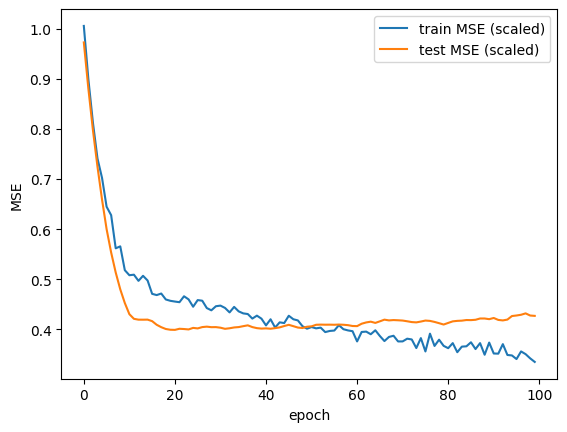

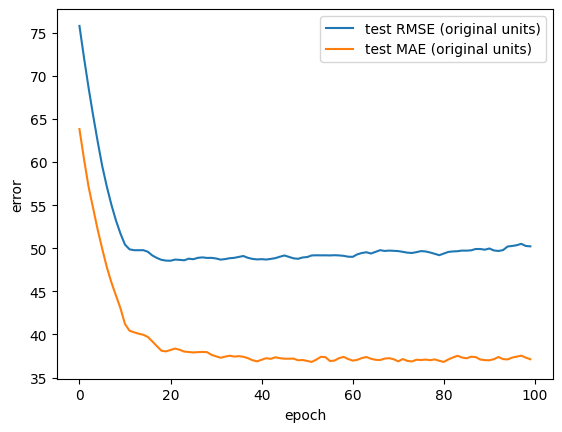

In [88]:

plt.figure()
plt.plot(history["train_mse"], label="train MSE (scaled)")
plt.plot(history["test_mse"], label="test MSE (scaled)")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["test_rmse_orig"], label="test RMSE (original units)")
plt.plot(history["test_mae_orig"], label="test MAE (original units)")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.show()

## 7) Inspect predictions (original scale)

We'll scatter plot predicted vs true.

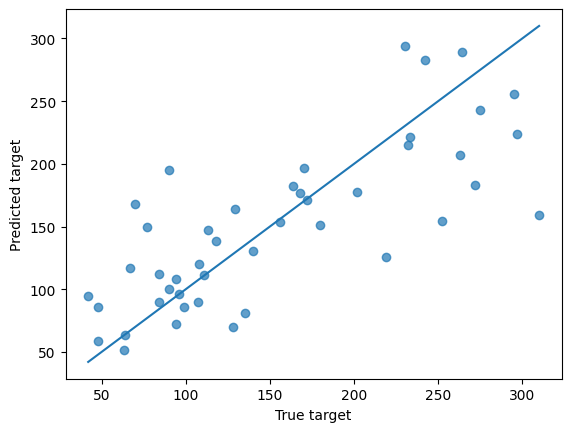

(50.22550222963181, np.float32(37.1262))

In [89]:

@torch.no_grad()
def collect_predictions(model, loader, y_mean: float, y_std: float):
    model.eval()
    preds = []
    trues = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)

        pred_orig = (pred * y_std + y_mean).cpu().numpy().reshape(-1)
        y_orig    = (yb   * y_std + y_mean).cpu().numpy().reshape(-1)
        preds.append(pred_orig)
        trues.append(y_orig)
    return np.concatenate(preds), np.concatenate(trues)

preds, trues = collect_predictions(model, test_loader, float(y_mean), float(y_std))

plt.figure()
plt.scatter(trues, preds, alpha=0.7)
plt.xlabel("True target")
plt.ylabel("Predicted target")
mn = min(trues.min(), preds.min())
mx = max(trues.max(), preds.max())
plt.plot([mn, mx], [mn, mx])
plt.show()

rmse = math.sqrt(np.mean((preds - trues) ** 2))
mae = np.mean(np.abs(preds - trues))
rmse, mae